Filtrado de spam en mensajes de texto (SMS)
===

* *45 min*

**Bibliografía.** Machine Learning with R. Brett Lantz, Packt Publishing, Second Edition, 2015.

Los clasificadores Bayesianos ingenuros son herramientas de gran utilidad para la construcción de sistemas de clasificación, como ya se discutio en los tutoriales anteriores. En este tutorial se utiliza un clasificador Bayesiano ingenuo para determinar si un mensaje SMS es válido o es spam.

Al finalizar este tutorial, usted estará en capacidad de:

* Aplicar técnicas de minería de texto para preprocesar información textual.


* Realizar el análisis exploratorio de textos.


* Construir un clasificador Bayesiano en el lenguaje R.


## Definición del problema

La recepción de publicidad no deseada a traves mensajes de texto usando SMS (Short Message Service) es un problema que afecta a muchos usuarios de teléfonos móviles. El problema radica en que los usuarios deben pagar por los mesajes recibidos, y por este motivo resulta muy importante que las compañías prestadoras del servicio puedan filtrar mensajes indeseados antes de enviarlos a su destinatario final. Los mensajes de texto  (SMS) tienen una longitud máxima de 160 caracteres, por lo que el texto resulta poco para realizar la clasificación, en comparación con textos más largos (como los emails). Adicionalmente, los errores de digitación dificultan el proceso de detección automática.   

Para construir el clasificador, se tiene una muestra que contiene 5574 mensajes en inglés, no codificados y clasificados como legítimos (ham) o spam que se encuentra disponible en http://www.dt.fee.unicamp.br/~tiago/smsspamcollection/. El problema en términos de los datos consiste en clasificar si un mensaje SMS es legítico o spam, a partir del análisis de las palabras que contiente, partiendo del supuesto de que ciertas palabras que son más frecuentes dependiendo del tipo de mensaje. Esto implica que en la fase de preparación de los datos se deben extraer las palabras que contiene cada mensaje para poder realizar el análsis.

## Solución

### Carga de datos

In [1]:
##
## Carga de los datos.
##
data <- read.csv("data/sms_spam.csv", stringsAsFactors = FALSE)

##
## Verificación de los datos cargados. Note que hay dos variables
## en el dataframe. Una es el tipo de mesaje como texto (columna type),
## y la otra es el mensaje como tal (columna text).
##
str(data)

'data.frame':	5574 obs. of  2 variables:
 $ type: chr  "ham" "ham" "spam" "ham" ...
 $ text: chr  "Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..." "Ok lar... Joking wif u oni..." "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question("| __truncated__ "U dun say so early hor... U c already then say..." ...


In [2]:
##
## Se convierte la columna type, que contiene strings, en un factor.
##
data$type <- factor(data$type)
str(data$type)

 Factor w/ 2 levels "ham","spam": 1 1 2 1 1 2 1 1 2 2 ...


### Conteo de cantidad de mensajes por tipo

In [3]:
##
## Se obtiene la cantidad de casos para 
## cada tipo de mensaje.
## 
table(data$type)


 ham spam 
4827  747 

In [4]:
##
## Se convierte el conteo anterior en probabilidades.
##
round(prop.table(table(data$type)) * 100, digits = 1)


 ham spam 
86.6 13.4 

### Construcción del Corpus

In [5]:
##
## El paquete tm se usa para minería de texto
##
# install.packages("tm")
# install.packages("NLP")
# install.packages("SnowballC")
##
library(NLP)
library(tm)
library(SnowballC)

##
## Se crea un corpus que es una colección de documentos.
## El corpus es simplemente una estructura de datos que
## permite que la aplicación eficiente (computacionalmente)
## de funciones que se usan para manipular texto. Algunos
## ejemplos de funciones comunes son presentados a 
## continuación
##
data_corpus <- VCorpus(VectorSource(data$text))
print(data_corpus)

<<VCorpus>>
Metadata:  corpus specific: 0, document level (indexed): 0
Content:  documents: 5574


In [6]:
##
## Se pueden seleccionar elementos particulares dentro del corpus.
##
inspect(data_corpus[1:2])

<<VCorpus>>
Metadata:  corpus specific: 0, document level (indexed): 0
Content:  documents: 2

[[1]]
<<PlainTextDocument>>
Metadata:  7
Content:  chars: 111

[[2]]
<<PlainTextDocument>>
Metadata:  7
Content:  chars: 29



In [7]:
##
## Para ver un mensaje de texto en particular se usa as.character
##
as.character(data_corpus[[1]])

[1] "Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."

In [8]:
## Para ver varios documentos se usa lapply
lapply(data_corpus[1:2], as.character)

$`1`
[1] "Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."

$`2`
[1] "Ok lar... Joking wif u oni..."

### Transformación del texto

El proceso de transformación tiene como fin realizar la preparación del texto para su procesamiento. En el siguiente fragmento de código se realizan las transformaciones típicas.

In [9]:
##
## Se convierten todas las letras en minúsculas. 
## 'a' y 'A' son cadenas de texto diferentes
##
data_corpus_clean <- tm_map(data_corpus, 
                            content_transformer(tolower))

##
## Se eliminan los dígitos. No aportan valor
## a la clasificación del documento.
##
data_corpus_clean <- tm_map(data_corpus_clean,
                            removeNumbers)

##
## Se eliminan las stop-words, que son palabras que embellecen 
## el texto y facilitan su comprensión (articulos, adverbios, etc)
## pero no aportan a la clasificación.
##
data_corpus_clean <- tm_map(data_corpus_clean,
                            removeWords, # funcion que remueve las palabras
                            stopwords()) # lista de palabras a remover


##
## Para un documento en español se usaría 
##
##     tm_map(data_corpus_clean,
##            removeWords, # funcion que remueve las palabras
##            stopwords('spanish'))
##


##
## Se remueve la puntuación. 
##
data_corpus_clean <- tm_map(data_corpus_clean, 
                            removePunctuation)

##
## Se transforman a infinitivo las conjugaciones.
## 'llover' y 'llueve' son palabras diferentes.
##
data_corpus_clean <- tm_map(data_corpus_clean, 
                            stemDocument)
##
## Para un documento en españo se usaría
##
##     tm_map(data_corpus_clean, 
##            stemDocument('spanish'))
##


##
## Se remueven espacios en blanco adicionales.
##
data_corpus_clean <- tm_map(data_corpus_clean, 
                            stripWhitespace)

##
## Para ver el efecto de las transformaciones
## realizadas, a continuación se muestran los 
## mensajes originales y los transformados.
##
## Mensajes antes de realizar la limpieza.
##
lapply(data_corpus[1:3], as.character)

$`1`
[1] "Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."

$`2`
[1] "Ok lar... Joking wif u oni..."

$`3`
[1] "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"

In [10]:
##
## Mensajes despues de realizar la limpieza.
##
lapply(data_corpus_clean[1:3], as.character)

$`1`
[1] "go jurong point crazi avail bugi n great world la e buffet cine got amor wat"

$`2`
[1] "ok lar joke wif u oni"

$`3`
[1] "free entri wkli comp win fa cup final tkts st may text fa receiv entri questionstd txt ratetc appli s"

### WordClouds

Para visualizar la frecuencia con que aparecen las palabras en un grupo de documentos, es mucho más usual la representación mediante una nube de palabras que usar un histograma.

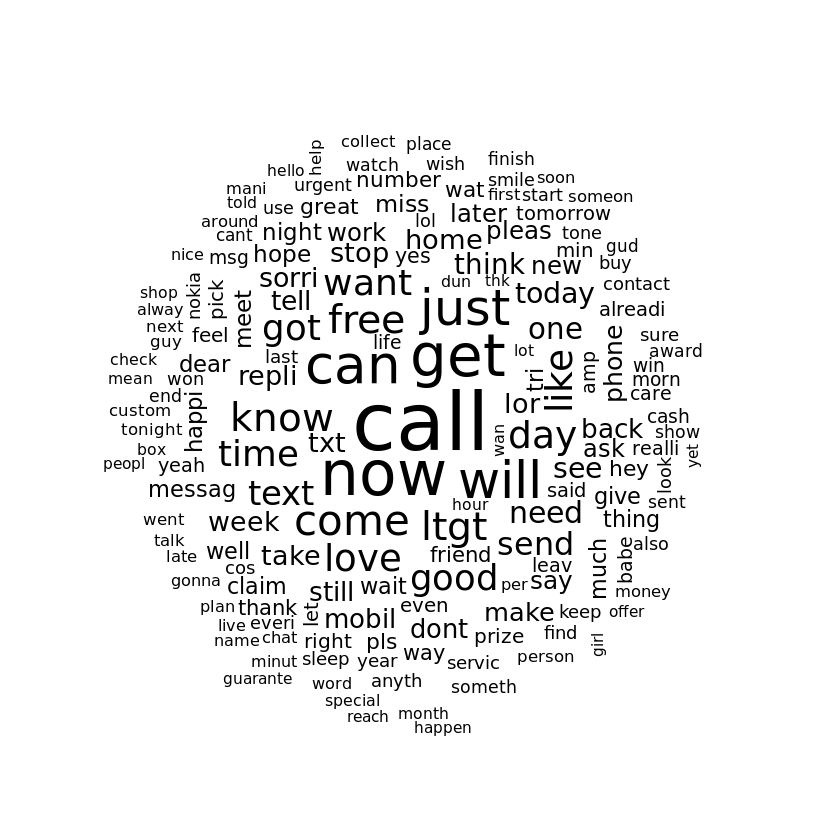

In [11]:
##
## En este caso es más útil visualizar 
## una nube que indique la frecuencia de las
## palabras
##
# install.packages("wordcloud")
# install.packages("RColorBrewer")
##
library(RColorBrewer)
library(wordcloud)
wordcloud(data_corpus_clean, 
          min.freq = 50,         # número de veces que debe aparecer una palabra
          random.order = FALSE)  # palabras más frecuentes en el centro

## Note que las palabras más comunes son call, get, now, can, just, ....

Warning message in tm_map.SimpleCorpus(corpus, tm::removePunctuation):
“transformation drops documents”Warning message in tm_map.SimpleCorpus(corpus, function(x) tm::removeWords(x, tm::stopwords())):
“transformation drops documents”

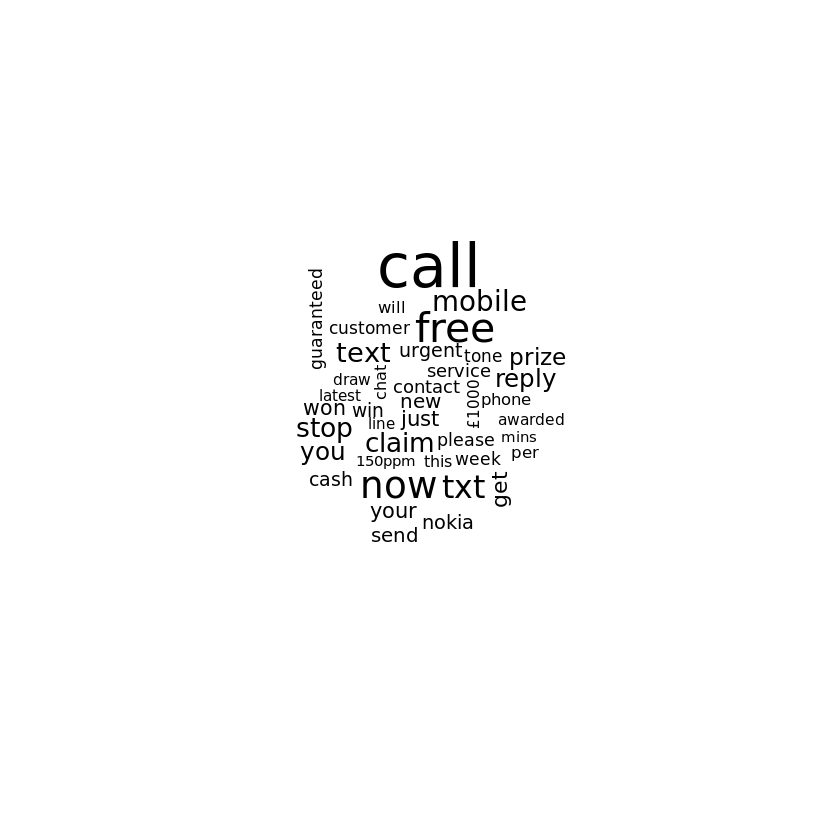

In [12]:
##
## Palabras que más aparecen en mensajes spam y válidos.
##
spam <- subset(data, type == "spam")
ham  <- subset(data, type == "ham")
wordcloud(spam$text, max.words = 40, scale = c(3, 0.5))

## las palabras más comunes en los mensajes spam son call, free, now, txt, ...

Warning message in tm_map.SimpleCorpus(corpus, tm::removePunctuation):
“transformation drops documents”Warning message in tm_map.SimpleCorpus(corpus, function(x) tm::removeWords(x, tm::stopwords())):
“transformation drops documents”

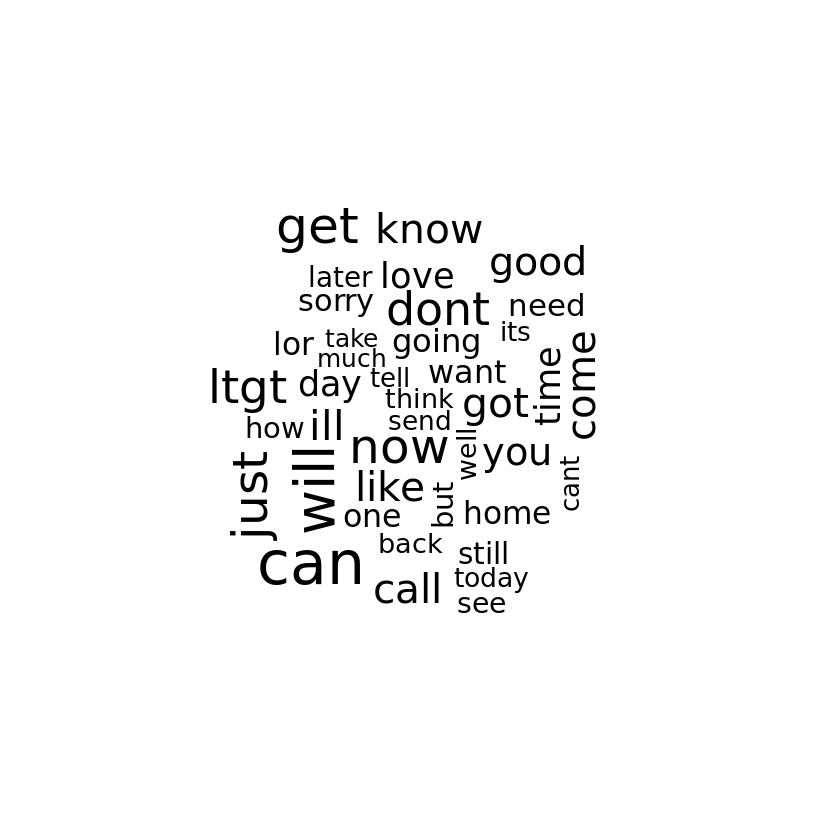

In [13]:
wordcloud(ham$text, max.words = 40, scale = c(3, 0.5))
## las palabras más comunes en los mensajes legítimos son can, know, get, just, will, ...

### Matriz de términos del documento

La matriz de términos del documento es una representación computacional que se usa para la construcción de clasificadores basados en texto. Consiste en una matriz donde los nombres de las columnas son las palabras que aparecen en el texto, mientras que las filas son los índices de los documentos.  

In [14]:
##
## Se crea la matriz de términos del documento
##
data_dtm <- DocumentTermMatrix(data_corpus_clean)

##
## Es posible crear la matriz de términos del documento
## sin pasar por el preprocesmiento previo y realizarlo
## directamente en la llamada a la función
##
data_dtm2 <- 
DocumentTermMatrix(data_corpus, 
                   control = list(tolower = TRUE, 
                                  removeNumbers = TRUE,
                                  stopwords = TRUE, 
                                  removePunctuation = TRUE,
                                  stemming = TRUE))

data_dtm

<<DocumentTermMatrix (documents: 5574, terms: 6592)>>
Non-/sparse entries: 42608/36701200
Sparsity           : 100%
Maximal term length: 40
Weighting          : term frequency (tf)

In [15]:
data_dtm2

<<DocumentTermMatrix (documents: 5574, terms: 6995)>>
Non-/sparse entries: 43713/38946417
Sparsity           : 100%
Maximal term length: 40
Weighting          : term frequency (tf)

### Conjuntos de entrenamiento y prueba

La información disponible se divide en dos conjuntos, uno para la construcción del clasificador (conjunto de entrenamiento) y otro para validar la precisión del clasificador (conjunto de prueba) por fuera de la muestra de datos usada para su creación. Véase https://en.wikipedia.org/wiki/Training,_validation,_and_test_sets.

Usualmente la distribución de datos entre los conjuntos de entrenamiento y prueba oscila entre el 60%-40% y el 80%-20%.

In [16]:
##
## Creación de los conjuntos de entrenamiento y prueba.
##
X_train      <- data_dtm[1:4169, ]
X_test       <- data_dtm[4170:5559, ]
y_train_true <- data[1:4169, ]$type
y_test_true  <- data[4170:5559, ]$type

##
## Distribución de los datos en el conjunto de entrenamiento.
##
print(prop.table(table(y_train_true)))
cat('\n')

##
## Distribución de los datos en el conjunto de prueba.
##
print(prop.table(table(y_test_true)))

y_train_true
      ham      spam 
0.8647158 0.1352842 

y_test_true
      ham      spam 
0.8697842 0.1302158 


In [17]:
##
## Se usarán las palabras que aparecen 
## al menos en 5 mensajes.
##
freq_words <- findFreqTerms(data_dtm, 5)
str(freq_words)

 chr [1:1417] "‘ll" "£wk" "abiola" "abl" "abt" "accept" "access" "account" ...


In [18]:
##
## Se construyen conjuntos de entrenamiento y prueba 
## con las palabras que aparecen al menos en 5 mensajes.
##
X_train <- X_train[ , freq_words]
X_test  <- X_test[  , freq_words]

In [19]:
##
## Se convierte la frecuencia de ocurrencia a "Yes" y "No"
##
convert_counts <- 
function(x) {
    x <- ifelse(x > 0, "Yes", "No")
}
##
X_train <- apply(X_train, MARGIN = 2, convert_counts)
X_test  <- apply(X_test,  MARGIN = 2, convert_counts)

### Construcción del clasificador en el lenguaje R

In [20]:
##
## Construye y entrena el clasificador.
## La librería contiene la implementación del clasificador en R.
## Consulte la ayuda del clasificador usando ?naiveBayes
##
# install.packages("e1071")
##
library(e1071)
clf <- naiveBayes(X_train, y_train_true)

### Evaluación del clasificador

In [21]:
##
## Se pronostica para los datos de prueba.
##
y_test_pred <- predict(clf, X_test)
head(y_test_pred)

[1] spam ham  ham  ham  ham  ham 
Levels: ham spam

In [22]:
##
## Se calcula la matriz de confusión.
##
table(y_test_true, y_test_pred)

           y_test_pred
y_test_true  ham spam
       ham  1202    7
       spam   24  157

In [23]:
##
## Se calcula la probabilidad de que cada mensaje sea 
## legítimo o spam para el conjunto de prueba. 
## Los resultados muestran que los mensajes
## son clasificados correctamente. En la siguiente tabla,
## cada fila es un mensaje, y los valores corresponden a las
## probabilidades calculadas de que dicho mensaje sea valido
## o spam. El mensaje se asigna a la clase (spam o legítimo)
## que tenga mayor probabilidad.
##
y_test_pred_prob <- predict(clf, X_test, type = "raw")
head(y_test_pred_prob)

ham,spam
1.346444e-14,1.000000e+00
9.968814e-01,3.118586e-03
9.999865e-01,1.348742e-05
1.000000e+00,8.470569e-09
9.999419e-01,5.805734e-05
9.999990e-01,9.947034e-07


In [24]:
##
## Resulta más conveniente preparar una nueva tabla que
## muestre la clasificación y no únicamente las 
## probabilidades.
##
results <- data.frame(actual_type  = y_test_true,
                      predict_type = y_test_pred,
                      prob_ham     = y_test_pred_prob[,1],
                      prob_spam    = y_test_pred_prob[,2])
head(results)

actual_type,predict_type,prob_ham,prob_spam
spam,spam,1.346444e-14,1.000000e+00
ham,ham,9.968814e-01,3.118586e-03
ham,ham,9.999865e-01,1.348742e-05
ham,ham,1.000000e+00,8.470569e-09
ham,ham,9.999419e-01,5.805734e-05
ham,ham,9.999990e-01,9.947034e-07


In [25]:
##
## Para el análisis resulta mejor construir la 
## matriz de confusión
##
# install.packages("gmodels")
##
library(gmodels)
CrossTable(y_test_pred, 
           y_test_true,
           prop.chisq = FALSE, 
           prop.t = FALSE,
           dnn = c('predicted', 'actual'))


 
   Cell Contents
|-------------------------|
|                       N |
|           N / Row Total |
|           N / Col Total |
|-------------------------|

 
Total Observations in Table:  1390 

 
             | actual 
   predicted |       ham |      spam | Row Total | 
-------------|-----------|-----------|-----------|
         ham |      1202 |        24 |      1226 | 
             |     0.980 |     0.020 |     0.882 | 
             |     0.994 |     0.133 |           | 
-------------|-----------|-----------|-----------|
        spam |         7 |       157 |       164 | 
             |     0.043 |     0.957 |     0.118 | 
             |     0.006 |     0.867 |           | 
-------------|-----------|-----------|-----------|
Column Total |      1209 |       181 |      1390 | 
             |     0.870 |     0.130 |           | 
-------------|-----------|-----------|-----------|

 


La matriz de confusión se encuentra descrita en el documento 'Construcción de clasificadores usando inducción de reglas' y en https://en.wikipedia.org/wiki/Confusion_matrix. 

La interpretación de la tabla es la siguiente:

* Las columnas corresponden a la clasificación real de los mensajes.

* Las filas corresponden a la clasificación asignada por el clasificador.

* Hay 1390 mensajes en total, de los cuales 1209 son legítimos y 181 son spam. De estos, el modelo clasificó 1226 (88.2%) como legítimos y 164 (11.8%) como spam.

* La celda superior izquierda indica que 1202 mensajes que son válidos fueron pronosticados correctamente como válidos, lo que equivale a una tasa del 99.4%; mientras que, 7 mensajes legítimos fueron clasificados como spam (0.6%). Las demás celdas centrales se leen de igual forma.

* El clasificador asignó la etiqueta legítimo a 1226 mensajes (88.2%). De estos, 1202 (98.0% de 1226) eran realmente legítimos, mientras que 24 (2.0% de 1226) eran realmente spam. 


In [26]:
##
## Mensajes con clasificación errónea.
## Resulta muy importante determinar porque los 
## mensajes están mal clasificados
##
head(subset(results, actual_type != predict_type))

,actual_type,predict_type,prob_ham,prob_spam
45,spam,ham,0.9324516266,0.067548373
54,ham,spam,0.0004048789,0.999595121
85,ham,spam,0.3110572471,0.688942753
88,spam,ham,0.9902648514,0.009735149
104,spam,ham,0.5295165195,0.470483481
130,spam,ham,0.9944769933,0.005523007


In [27]:
##
## Sin embargo, es mucho más intersante extraer
## mensajes con probabilidades numéricamente 
## cercanas a 0.5. Estos podrían generar ambiguedad
## en la clasificación.
##
head(subset(results, prob_spam > 0.40 & prob_spam < 0.60))

,actual_type,predict_type,prob_ham,prob_spam
104,spam,ham,0.5295165,0.4704835
320,ham,ham,0.5111674,0.4888326
694,ham,ham,0.5325186,0.4674814
709,spam,ham,0.5295165,0.4704835
817,spam,ham,0.5295165,0.4704835
873,spam,ham,0.5295165,0.4704835


Estos casos son los problemáticos, ya que existe muy poca evidencia (probabilidad cercana al 50%) de que pertenezcan a una clase o a otra. El analísta debe realizar una investigación, caso por caso, que permita determinar las causas de esta situación (información faltante, casos mal etiquetados, información errónea, necesidad de un clasificador más potente, etc.)

In [28]:
##
## Mensajes mal clasificados con probabilidad cercana a 0.5 
##
head(subset(results, prob_spam > 0.40 & prob_spam < 0.60 & actual_type != predict_type))

,actual_type,predict_type,prob_ham,prob_spam
104,spam,ham,0.5295165,0.4704835
709,spam,ham,0.5295165,0.4704835
817,spam,ham,0.5295165,0.4704835
873,spam,ham,0.5295165,0.4704835
1048,spam,ham,0.5295165,0.4704835


**Actividad.--** El código presentado a continuación genera una curva ROC para este clasificador. Cómo se interpreta?

### Mejora del modelo

**Actividad.** Si en la construcción del clasificador se hace `laplace = 1`, en cuanto mejora la precisión del modelo? Nota: este es un parámetro de la función `naiveBayes`.

---